### **Import Liberaries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.linear_model import BayesianRidge
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import joblib

C:\Users\user6\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\user6\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


### **Loading Dataset**

In [3]:
df = pd.read_csv("data.csv")
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### **Explore Data Analysis (EDA)**

In [4]:
df.shape

(4600, 18)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [7]:
cat_columns = df.select_dtypes(include='object').columns
for col in cat_columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("-" * 30)

Column: date
date
2014-06-23 00:00:00    142
2014-06-25 00:00:00    131
2014-06-26 00:00:00    131
2014-07-08 00:00:00    127
2014-07-09 00:00:00    121
                      ... 
2014-06-07 00:00:00      4
2014-07-06 00:00:00      3
2014-05-11 00:00:00      2
2014-07-04 00:00:00      2
2014-05-17 00:00:00      1
Name: count, Length: 70, dtype: int64
------------------------------
Column: street
street
2520 Mulberry Walk NE    4
2500 Mulberry Walk NE    3
Burke-Gilman Trail       2
23017 SE 281st Ct        2
35229 SE Terrace St      2
                        ..
501 N 143rd St           1
14855 SE 10th Pl         1
759 Ilwaco Pl NE         1
5148 S Creston St        1
18717 SE 258th St        1
Name: count, Length: 4525, dtype: int64
------------------------------
Column: city
city
Seattle                1573
Renton                  293
Bellevue                286
Redmond                 235
Kirkland                187
Issaquah                187
Kent                    185
Auburn      

C:\Users\user6\AppData\Local\Temp\ipykernel_6504\564387828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_columns = df.select_dtypes(include='object').columns


In [8]:
df.isna().sum()

date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64

In [9]:
df.duplicated().sum()

0

### **Data Preprocessing**

In [10]:
print(f"Old Shape: {df.shape}")
df = df.drop(['country','street'], axis=1)
print(f"New shape: {df.shape}")

Old Shape: (4600, 18)
New shape: (4600, 16)


In [11]:
df['date'] = pd.to_datetime(df['date'])

df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

df = df.drop(columns=['date'])
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,year,month,day
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,2014,5,2
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,2014,5,2
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,2014,5,2
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,2014,5,2
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,2014,5,2


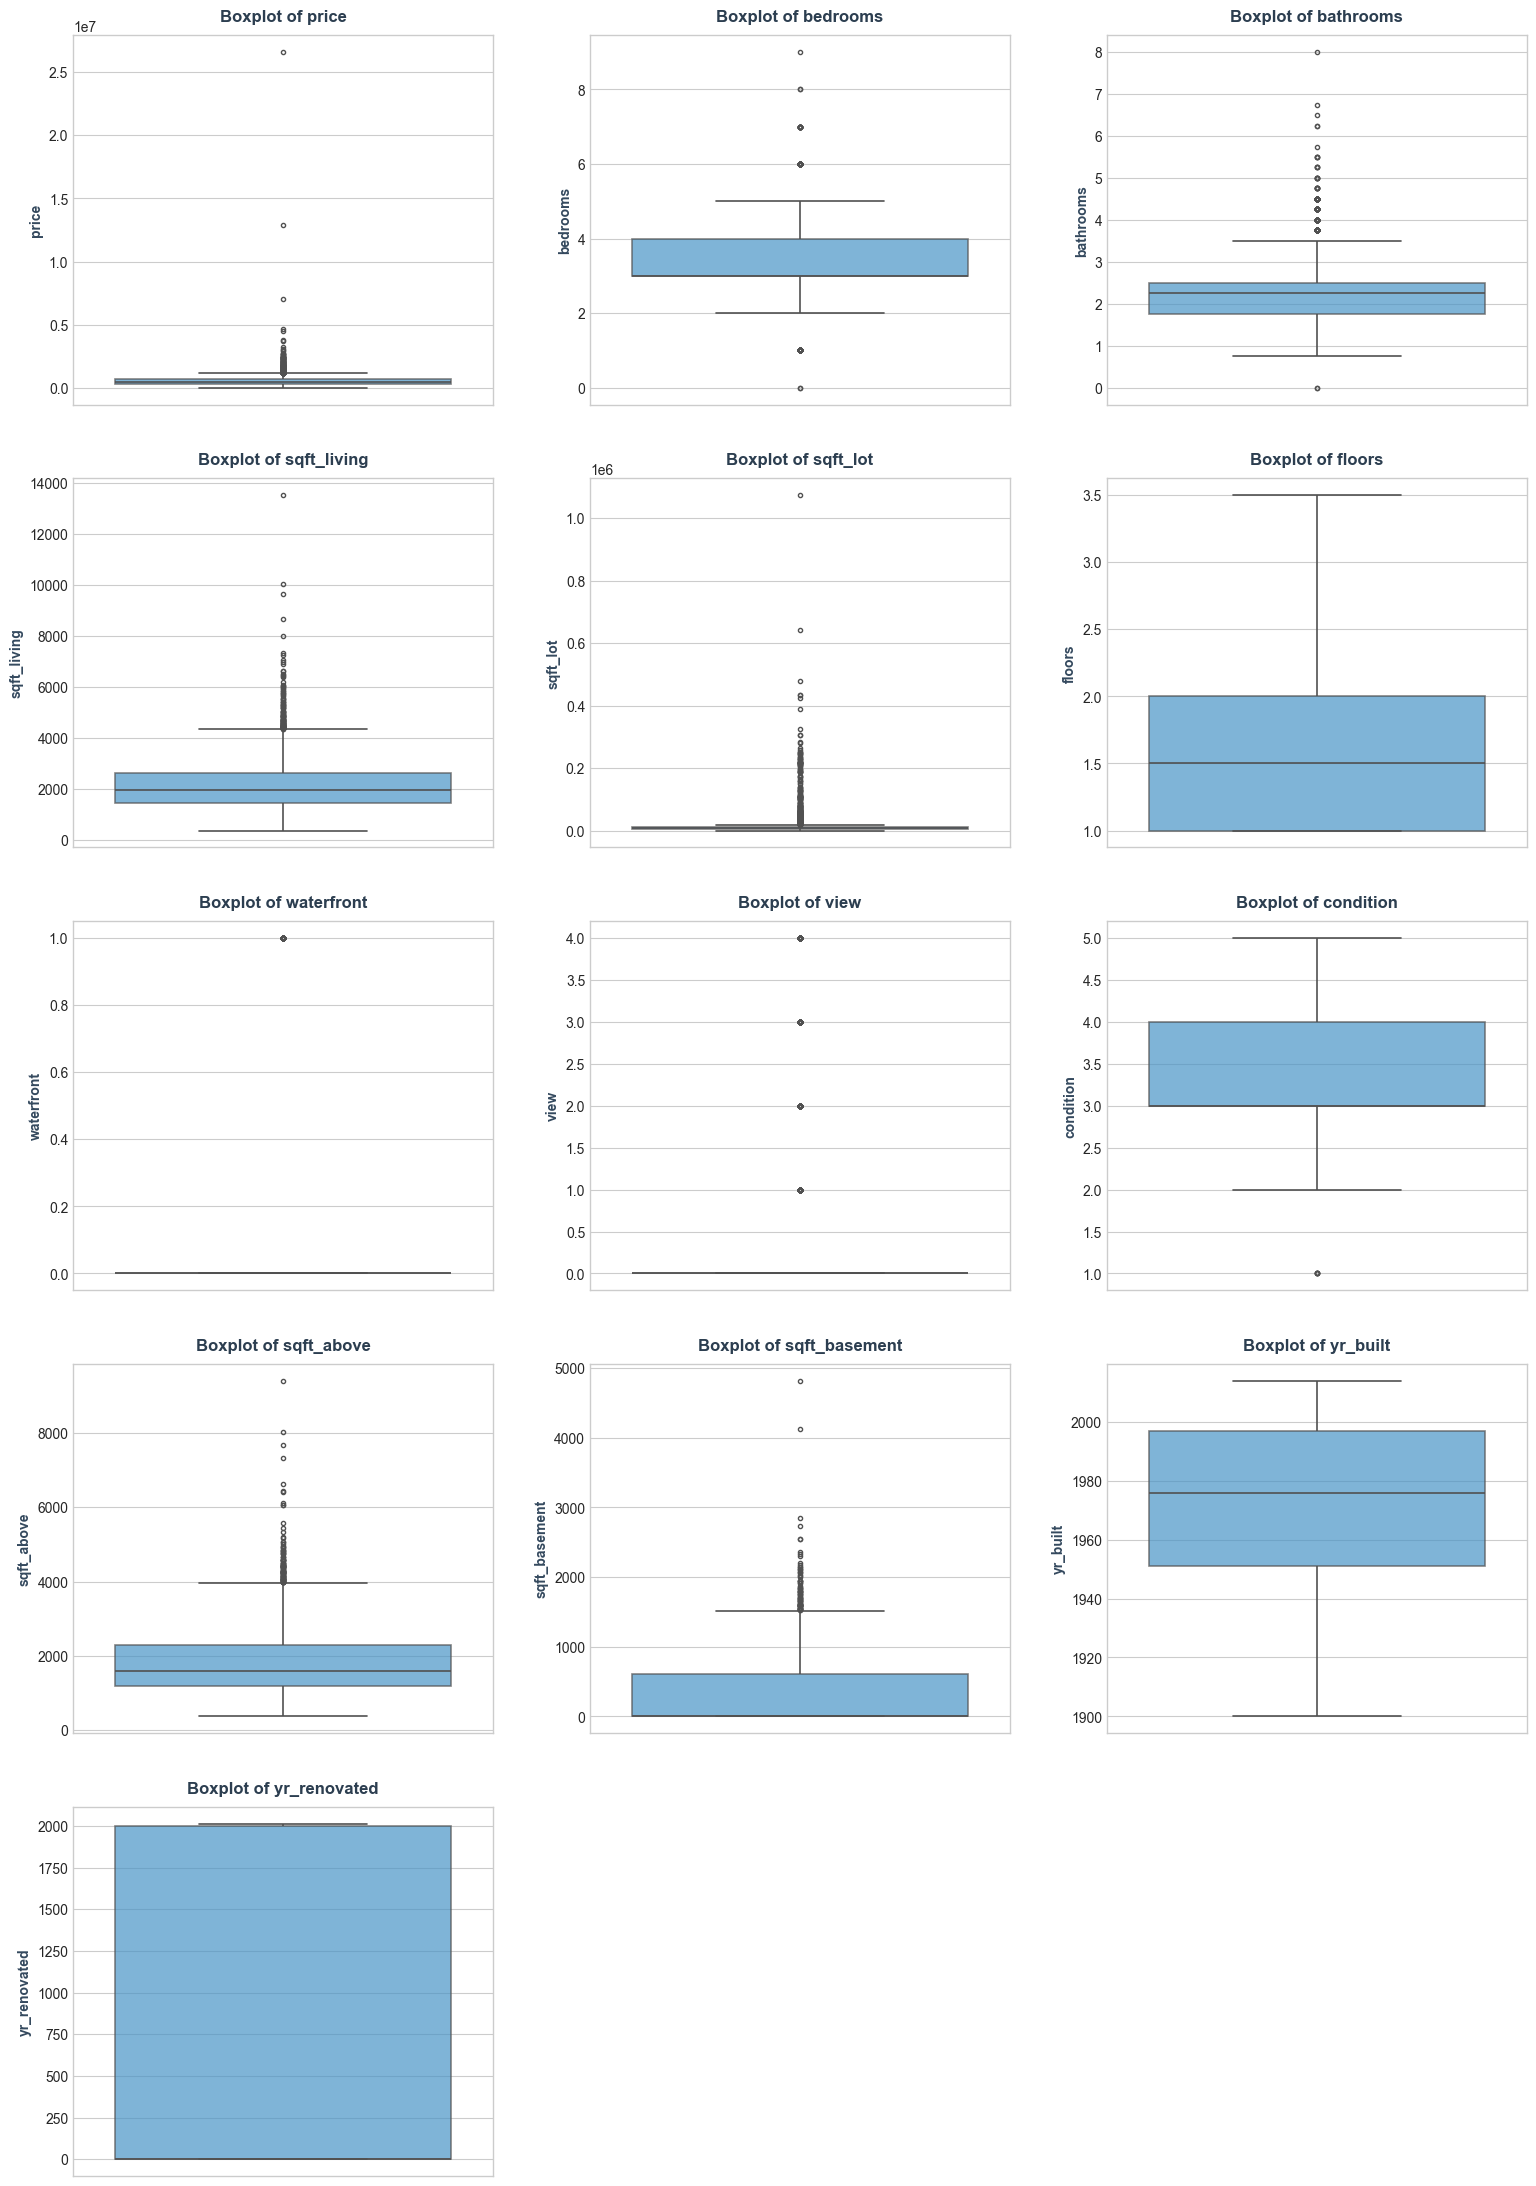

In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
num_cols = len(numerical_cols)

rows = (num_cols // 3) + (1 if num_cols % 3 != 0 else 0)

plt.figure(figsize=(16, rows * 4.5))
plt.style.use('seaborn-v0_8-whitegrid')

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, 3, i)
    
    ax = sns.boxplot(
        y=df[col], 
        color='#3498db', 
        fliersize=3, 
        linewidth=1.2,
        boxprops=dict(alpha=0.7)
    )
    
    plt.title(f'Boxplot of {col}', fontsize=12, fontweight='bold', pad=10, color='#2c3e50')
    plt.ylabel(col, fontsize=10, fontweight='semibold', color='#34495e')
    plt.xlabel('')

plt.tight_layout(pad=3.0)
plt.show()

In [13]:
initial_count = len(df)
df = df[df['price'] > 0]
removed_count = initial_count - len(df)

print("=" * 50)
print(f"Cleaning Zero Prices")
print("=" * 50)
print(f"Number of removed rows with price = 0 : {removed_count}")
print(f"Current DataFrame shape: {df.shape}")
print("=" * 50)

Cleaning Zero Prices
Number of removed rows with price = 0 : 49
Current DataFrame shape: (4551, 18)


In [14]:
initial_count = len(df)
df = df[(df['bedrooms'] > 0) & (df['bathrooms'] > 0)]
removed_count = initial_count - len(df)

print("=" * 50)
print(f"Cleaning Zero Bedrooms/Bathrooms")
print("=" * 50)
print(f"Number of removed rows: {removed_count}")
print(f"Current DataFrame shape: {df.shape}")
print("=" * 50)

Cleaning Zero Bedrooms/Bathrooms
Number of removed rows: 2
Current DataFrame shape: (4549, 18)


In [15]:
Q1 = df['sqft_living'].quantile(0.25)
Q3 = df['sqft_living'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

initial_count = len(df)
df = df[(df['sqft_living'] >= lower_bound) & (df['sqft_living'] <= upper_bound)]
removed_count = initial_count - len(df)

print("=" * 50)
print(f"Handling Extreme Outliers in sqft_living")
print("=" * 50)
print(f"Number of extreme outlier rows removed: {removed_count}")
print(f"Final DataFrame shape after cleaning: {df.shape}")
print("=" * 50)

Handling Extreme Outliers in sqft_living
Number of extreme outlier rows removed: 127
Final DataFrame shape after cleaning: (4422, 18)


### **Visualization**

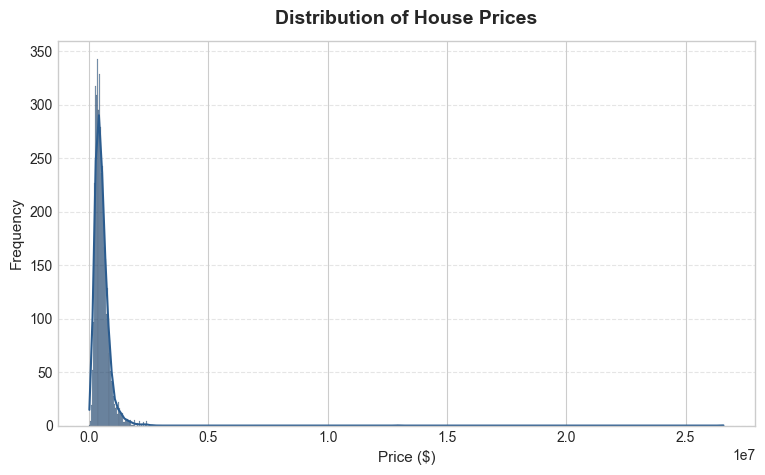

In [16]:
plt.figure(figsize=(9, 5))
sns.histplot(df['price'], kde=True, color='#2b5c8f', edgecolor='black', alpha=0.6)
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Price ($)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

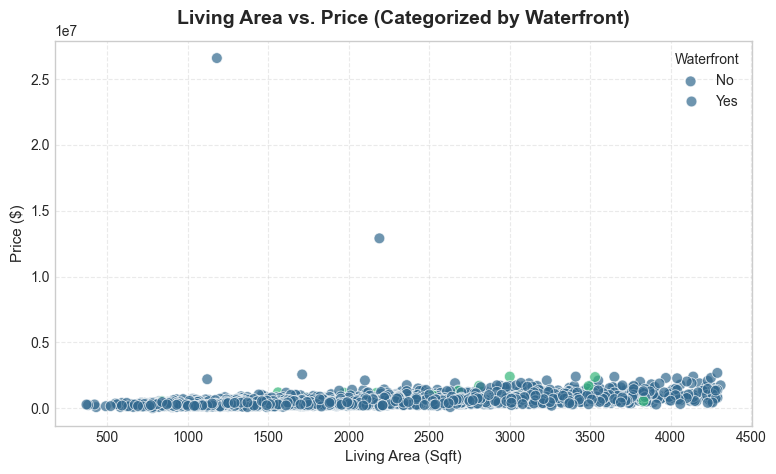

In [17]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df, 
    x='sqft_living', 
    y='price', 
    hue='waterfront', 
    palette='viridis', 
    alpha=0.7, 
    s=60
)
plt.title('Living Area vs. Price (Categorized by Waterfront)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Living Area (Sqft)', fontsize=11)
plt.ylabel('Price ($)', fontsize=11)
plt.legend(title='Waterfront', labels=['No', 'Yes'])
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

C:\Users\user6\AppData\Local\Temp\ipykernel_6504\1011921979.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


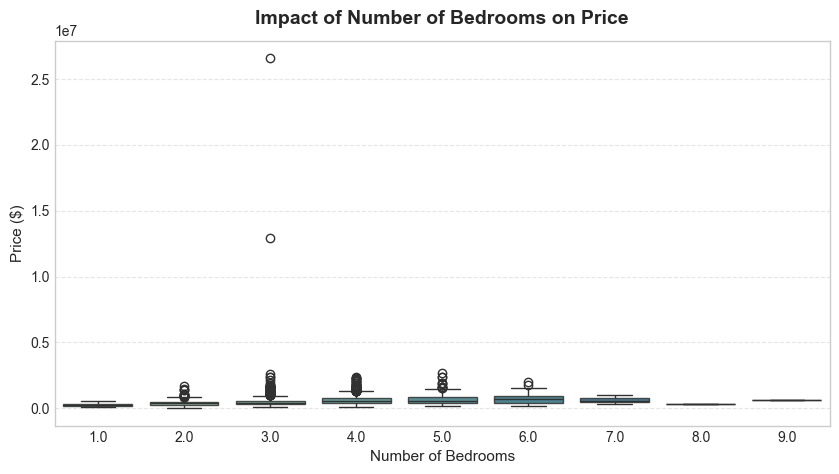

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df, 
    x='bedrooms', 
    y='price', 
    palette='crest', 
    boxprops=dict(alpha=0.85)
)
plt.title('Impact of Number of Bedrooms on Price', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Number of Bedrooms', fontsize=11)
plt.ylabel('Price ($)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

C:\Users\user6\AppData\Local\Temp\ipykernel_6504\2166845426.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


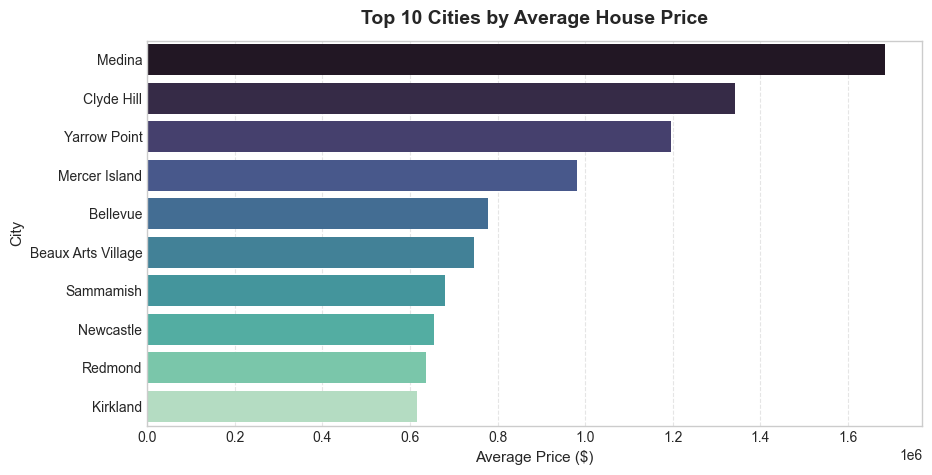

In [19]:
plt.figure(figsize=(10, 5))
top_cities = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10).reset_index()

sns.barplot(
    data=top_cities, 
    x='price', 
    y='city', 
    palette='mako'
)
plt.title('Top 10 Cities by Average House Price', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Average Price ($)', fontsize=11)
plt.ylabel('City', fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

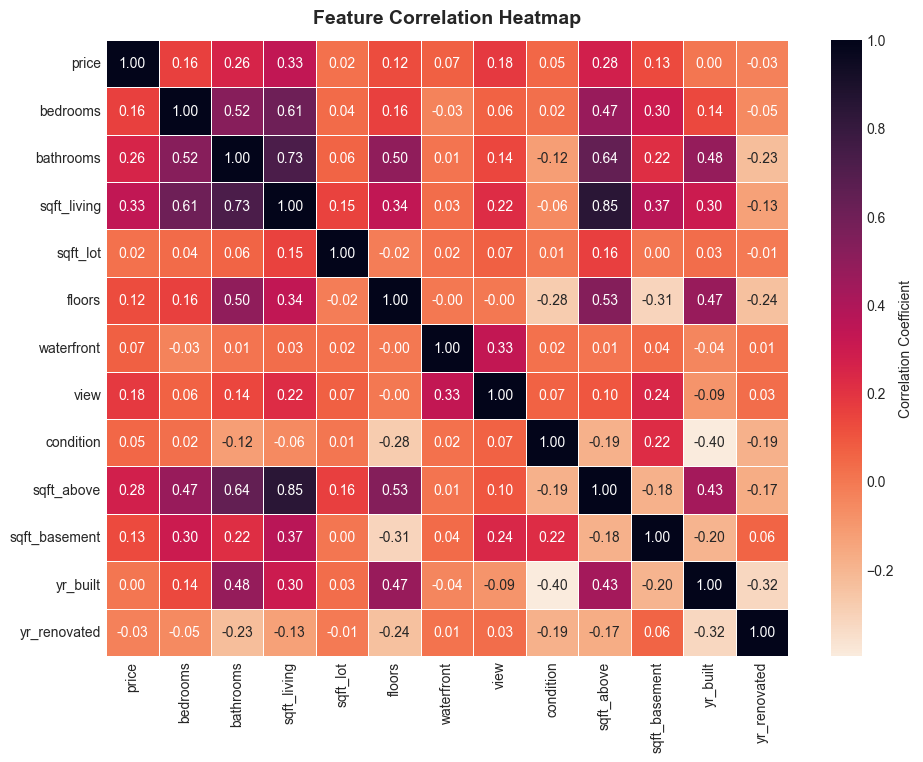

In [20]:
plt.figure(figsize=(11, 8))
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix setup
corr_matrix = numerical_df.corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='rocket_r', 
    linewidths=0.7, 
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.show()

In [21]:
df = pd.get_dummies(df, columns=['city', 'statezip'], drop_first=True, dtype=int)

print("=" * 60)
print("After Applying One-Hot Encoding for City and Statezip")
print("=" * 60)
print("Final number of columns:", df.shape[1])
print("=" * 60)

After Applying One-Hot Encoding for City and Statezip
Final number of columns: 135


### **Identify Target**

In [22]:
X = df.drop(columns=['price'])
y = df['price']

### **Splitting Data**

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    )

### **Scaling**

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Training Model**

In [25]:
models = {
    'SVR': SVR(),
    'XGBRegressor': XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    'Ridge': Ridge(),
    'BayesianRidge': BayesianRidge(),
    'LinearRegression': LinearRegression(),
    'RandomForestRegressor': RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )
}

In [26]:
model_results = []

for name, model in models.items():

    if name in ["RandomForestRegressor", "XGBRegressor"]:
        model.fit(X_train, y_train)
        predicted = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        predicted = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, predicted)
    rmse = np.sqrt(mean_squared_error(y_test, predicted))
    r2 = r2_score(y_test, predicted)

    model_results.append([name, mae, rmse, r2])

In [27]:
df_results = pd.DataFrame(
    model_results,
    columns=["Model", "MAE", "RMSE", "R² Score"]
)

df_results = (
    df_results
    .sort_values(by="RMSE")
    .reset_index(drop=True)
)

df_results.index += 1

df_results

,Model,MAE,RMSE,R² Score
1,BayesianRidge,101561.805629,183689.223356,0.650065
2,Ridge,103991.858618,184428.462230,0.647243
3,LinearRegression,104016.004673,184444.999323,0.647180
4,RandomForestRegressor,105965.360799,197835.521621,0.594091
5,XGBRegressor,103988.521025,244447.251941,0.380288
6,SVR,212780.937299,322685.272747,-0.079887


##### **Best Model Selection**
***BayesianRidge** achieved the lowest RMSE, the lowest MAE, and the highest R² score among all evaluated models. Therefore, it was selected as the final model for deployment.*

In [28]:
best_model = BayesianRidge()
best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

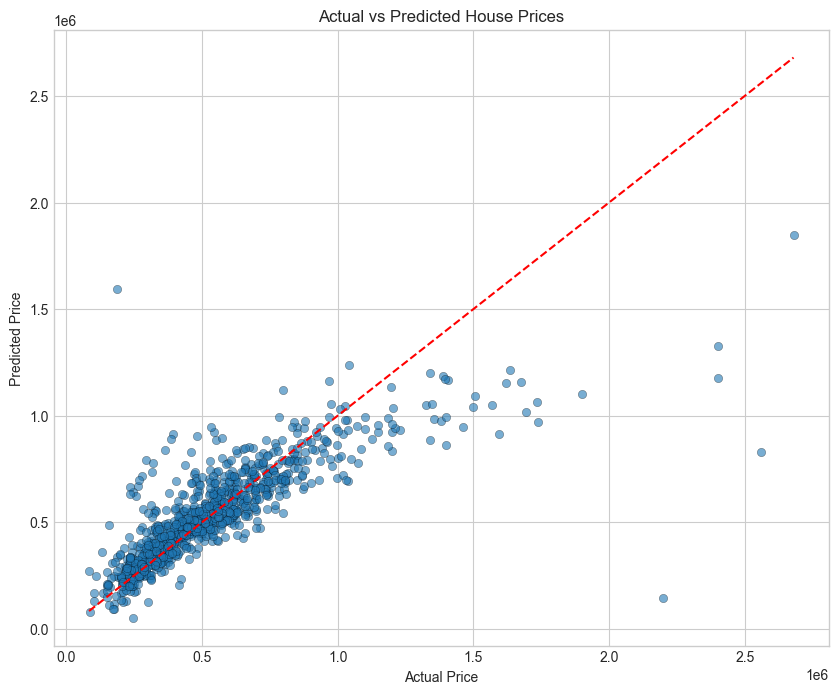

In [29]:
plt.figure(figsize=(10,8))

plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="black", linewidth=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

### **Model Export**

In [30]:
joblib.dump(best_model, "house_price.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Model, Scaler and feature columns saved successfully!")

Model, Scaler and feature columns saved successfully!
